
--- Feed System 1 ---
Line ID         : 0.305 in
Line length     : 120.000 in
Velocity        : 19.116 ft/s
Line dp         : 12.627 psid
Valve 1 dp      : 6.955 psid
Valve 2 dp      : 31.936 psid
Total dp        : 51.519 psid
Outlet pressure : 601.151 psia

--- Feed System 2 ---
Line ID         : 0.402 in
Line length     : 120.000 in
Velocity        : 11.004 ft/s
Line dp         : 3.455 psid
Valve 1 dp      : 6.955 psid
Valve 2 dp      : 31.936 psid
Total dp        : 42.346 psid
Outlet pressure : 610.324 psia

--- Feed System 3 ---
Line ID         : 0.500 in
Line length     : 120.000 in
Velocity        : 7.113 ft/s
Line dp         : 1.251 psid
Valve 1 dp      : 6.955 psid
Valve 2 dp      : 31.936 psid
Total dp        : 40.142 psid
Outlet pressure : 612.528 psia


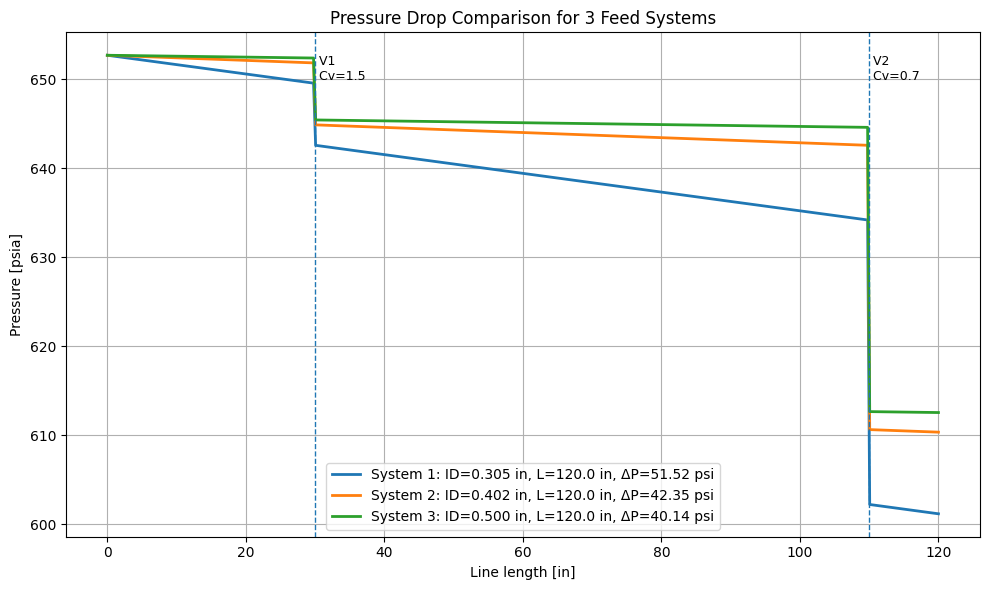

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from rocketprops.rocket_prop import get_prop
from rocketprops.line_supt import calc_line_vel_dp
from rocketprops.valve_supt import cv_valve_dp


def build_feed_system_profile(
    mdot_lbm_s,
    p_in_psia,
    T_degR,
    line_id_in,
    line_length_in,
    valve_positions_in,
    valve_cvs,
    roughness_in=5.0e-6,
    extra_K_total=0.0,
    n_points=300,
):
    """
    Build pressure profile for one feed system with:
      - one line
      - two or more valves in series

    Parameters
    ----------
    mdot_lbm_s : float
        Mass flow rate [lbm/s]
    p_in_psia : float
        Inlet pressure [psia]
    T_degR : float
        Fluid temperature [degR]
    line_id_in : float
        Feed line ID [in]
    line_length_in : float
        Total feed line length [in]
    valve_positions_in : list[float]
        Valve positions along the line [in]
    valve_cvs : list[float]
        Valve Cv values
    roughness_in : float
        Pipe roughness [in]
    extra_K_total : float
        Total non-valve minor loss coefficient
    n_points : int
        Number of x-points in the profile

    Returns
    -------
    dict
    """
    if len(valve_positions_in) != len(valve_cvs):
        raise ValueError("valve_positions_in and valve_cvs must have the same length")

    if any(x < 0.0 or x > line_length_in for x in valve_positions_in):
        raise ValueError("All valve positions must be within the line length")

    prop = get_prop("N2O")

    # Distributed line loss + non-valve K losses
    vel_fps, dp_line_psid = calc_line_vel_dp(
        pObj=prop,
        TdegR=T_degR,
        Ppsia=p_in_psia,
        wdotPPS=mdot_lbm_s,
        IDinches=line_id_in,
        roughness=roughness_in,
        Kfactors=extra_K_total,
        len_inches=line_length_in,
    )

    # Valve losses
    dp_valves_psid = []
    for cv in valve_cvs:
        dpv = cv_valve_dp(
            pObj=prop,
            Cv=cv,
            wdotPPS=mdot_lbm_s,
            TdegR=T_degR,
            Ppsia=p_in_psia,
        )
        dp_valves_psid.append(dpv)

    valves = sorted(zip(valve_positions_in, valve_cvs, dp_valves_psid), key=lambda t: t[0])

    # Pressure profile
    x_in = np.linspace(0.0, line_length_in, n_points)
    p_psia = p_in_psia - dp_line_psid * (x_in / line_length_in)

    # Add valve step losses
    for xpos, cv, dpv in valves:
        p_psia -= dpv * (x_in >= xpos)

    dp_total_psid = dp_line_psid + sum(dp_valves_psid)
    p_out_psia = p_in_psia - dp_total_psid

    return {
        "x_in": x_in,
        "p_psia": p_psia,
        "vel_fps": vel_fps,
        "dp_line_psid": dp_line_psid,
        "dp_valves_psid": dp_valves_psid,
        "dp_total_psid": dp_total_psid,
        "p_out_psia": p_out_psia,
        "line_id_in": line_id_in,
        "line_length_in": line_length_in,
        "valves": valves,
    }


def compare_three_feed_systems(
    mdot_lbm_s,
    p_in_psia,
    T_degR,
    line_lengths_in,
    line_ids_in,
    valve_positions_in,
    valve_cvs,
    roughness_in=5.0e-6,
    extra_K_totals=None,
    n_points=300,
):
    """
    Compare 3 different feed systems with the same valves.

    Parameters
    ----------
    line_lengths_in : list[float]
        Lengths of the 3 systems [in]
    line_ids_in : list[float]
        Diameters (IDs) of the 3 systems [in]
    valve_positions_in : list[float]
        Same valve locations for each system [in]
    valve_cvs : list[float]
        Same valve Cvs for each system
    extra_K_totals : list[float] or None
        Total non-valve K for each system
    """
    if len(line_lengths_in) != 3 or len(line_ids_in) != 3:
        raise ValueError("line_lengths_in and line_ids_in must each contain exactly 3 values")

    if extra_K_totals is None:
        extra_K_totals = [0.0, 0.0, 0.0]

    if len(extra_K_totals) != 3:
        raise ValueError("extra_K_totals must have exactly 3 values")

    results = []

    for i in range(3):
        res = build_feed_system_profile(
            mdot_lbm_s=mdot_lbm_s,
            p_in_psia=p_in_psia,
            T_degR=T_degR,
            line_id_in=line_ids_in[i],
            line_length_in=line_lengths_in[i],
            valve_positions_in=valve_positions_in,
            valve_cvs=valve_cvs,
            roughness_in=roughness_in,
            extra_K_total=extra_K_totals[i],
            n_points=n_points,
        )
        results.append(res)

    return results


def plot_three_feed_systems(results):
    """
    Plot pressure vs line length for 3 feed systems.
    """
    plt.figure(figsize=(10, 6))

    for i, res in enumerate(results, start=1):
        label = (
            f"System {i}: ID={res['line_id_in']:.3f} in, "
            f"L={res['line_length_in']:.1f} in, "
            f"ΔP={res['dp_total_psid']:.2f} psi"
        )
        plt.plot(res["x_in"], res["p_psia"], label=label, linewidth=2)

    # Mark valve positions using the first system only
    for j, (xpos, cv, dpv) in enumerate(results[0]["valves"], start=1):
        plt.axvline(x=xpos, linestyle="--", linewidth=1)
        plt.text(
            xpos,
            results[0]["p_psia"][0],
            f" V{j}\n Cv={cv}",
            va="top",
            fontsize=9,
        )

    plt.xlabel("Line length [in]")
    plt.ylabel("Pressure [psia]")
    plt.title("Pressure Drop Comparison for 3 Feed Systems")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Same operating condition for all 3 systems
    mdot_lbm_s = 0.25 # for ref 0.5 lbs = .2267 kg/s
    p_in_psia = 652.67
    T_degR = 518 #15 deg celsius

    # Same two valves in all three systems
    valve_positions_in = [30.0, 110.0]
    valve_cvs = [1.5, 0.7]

    # Three different feed systems
    line_lengths_in = [120.0, 120.0, 120.0]
    line_ids_in = [0.305, 0.402, 0.5]

    # Optional non-valve minor losses for each system
    extra_K_totals = [1.0, 1.0, 1.0]

    results = compare_three_feed_systems(
        mdot_lbm_s=mdot_lbm_s,
        p_in_psia=p_in_psia,
        T_degR=T_degR,
        line_lengths_in=line_lengths_in,
        line_ids_in=line_ids_in,
        valve_positions_in=valve_positions_in,
        valve_cvs=valve_cvs,
        roughness_in=5.0e-6,
        extra_K_totals=extra_K_totals,
        n_points=400,
    )

    for i, res in enumerate(results, start=1):
        print(f"\n--- Feed System {i} ---")
        print(f"Line ID         : {res['line_id_in']:.3f} in")
        print(f"Line length     : {res['line_length_in']:.3f} in")
        print(f"Velocity        : {res['vel_fps']:.3f} ft/s")
        print(f"Line dp         : {res['dp_line_psid']:.3f} psid")
        for j, dpv in enumerate(res["dp_valves_psid"], start=1):
            print(f"Valve {j} dp      : {dpv:.3f} psid")
        print(f"Total dp        : {res['dp_total_psid']:.3f} psid")
        print(f"Outlet pressure : {res['p_out_psia']:.3f} psia")

    plot_three_feed_systems(results)



In [ ]:
import numpy as np
from rocketprops.rocket_prop import get_prop
import CoolProp.CoolProp as CP
# --- Constants ---
GPM_TO_M3S = 6.309e-5
PSI_TO_PA = 6894.76
RHO_WATER = 1000.0

def cv_to_mdot(Cv, dP_pa, rho, T_K):
    T_R = T_K * 1.8
    SG = rho/RHO_WATER
    dP_psi = dP_pa / PSI_TO_PA
    Q_gpm = Cv * np.sqrt(dP_psi / SG)
    Q_m3s = Q_gpm * 6.309e-5
    m_dot = rho * Q_m3s
    return m_dot


Cv = 1.5                  # valve Cv from DK- Lok
dP = 5e5                  # pressure drop [Pa]
D = 4.8e-3                  # seat diameter
A = np.pi * (D/2)**2      # area [m^2]

fluid = "N2O"
T = 280.0                 # K
P = 5e6                   # Pa (upstream)
rho = CP.PropsSI('D', 'P', P, 'T', T, 'N2O') # kg/m^3
# mass flow from Cv (water-based)
m_dot_cv = cv_to_mdot(Cv, dP, rho, T)
# solve Cd
CdA = m_dot_cv / ( np.sqrt(2 * rho * dP))
print(f"Density: {rho:.1f} kg/m^3")
print(f"Mass flow (from Cv): {m_dot_cv:.4f} kg/s")
print(f"Solved CdA: {CdA:.7f}")

Density: 883.0 kg/m^3
Mass flow (from Cv): 0.7573 kg/s
Solved CdA: 0.0000255
